# Phase 1 Experiments: Joint Contrastive + Regression Training

This notebook explores a multi-objective training strategy that combines contrastive learning (for metric-text matching) with regression heads (for precise score prediction) and ranking constraints (for ordinal consistency). The key innovation is training all three components simultaneously rather than sequentially, allowing the router and experts to co-adapt.

**Expected improvements over pure contrastive baselines:**
- Better calibration for low-score samples (via weighted MSE on the low expert)
- More accurate high-score predictions (via dedicated high expert)
- Preserved ranking relationships (via pairwise hinge loss)
- Joint optimization should yield better routing decisions since the router sees regression feedback during training


### Core dependencies
Standard PyTorch + SentenceTransformers stack for neural training and embedding generation.


In [1]:
import os
import random
import json
import copy
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer

print("Torch version:", torch.__version__)


Torch version: 2.9.0


### Experimental hyperparameters
**Key differences from baseline:**
- `RANK_WEIGHT=2.0`: Stronger emphasis on preserving score orderings (higher than baseline 0.2)
- `LOW_SCORE_THRESH=5.0`: Lower routing threshold to capture more low-score samples in the specialized expert
- `TEXT_BATCH_SIZE_TRAIN=256`: Larger batches for more stable joint gradients
- `NEG_K=3`: More negative samples per anchor for richer contrastive signal

These values were tuned to balance the three loss components (contrastive, regression, ranking) without any single term dominating.


In [2]:
SEED = 42
BATCH_SIZE_ENCODE = 2
TEXT_BATCH_SIZE_TRAIN = 256
NEG_K = 3
CONTRASTIVE_EPOCHS = 12
N_FOLDS = 10
EMBEDDING_MODEL = "google/embeddinggemma-300m"
FORCE_CPU = True
REG_WEIGHT = 0.1
LOW_SCORE_THRESH = 5.0
LOW_SCORE_MULT = 12.0
NEG_SCORE_THRESH = 6.0
RANK_MARGIN = 1.0
RANK_WEIGHT = 2.0
TRAIN_JSON = "data/train_data.json"
TEST_JSON = "data/test_data.json"
METRIC_NAMES_JSON = "data/metric_names.json"
SAMPLE_SUB = "data/sample_submission.csv"

TRAIN_EMB_NPY = "saved_embeddings/train_text_embeddings.npy"
TEST_EMB_NPY = "saved_embeddings/test_text_embeddings.npy"
METRIC_EMB_NPY = "data/metric_name_embeddings.npy"


### Device selection & reproducibility
Forces CPU execution to ensure consistent timing and memory behavior across runs. All random seeds are fixed to enable exact reproduction of training dynamics.


In [3]:
if FORCE_CPU:
    DEVICE = "cpu"
    print("Forcing CPU usage (FORCE_CPU=True)")
elif torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print("Using device:", DEVICE)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.startswith("cuda"):
    torch.cuda.manual_seed_all(SEED)


Forcing CPU usage (FORCE_CPU=True)
Using device: cpu


### Data loading & embedding utilities
Lightweight helpers for JSON parsing, Gemma-style document formatting, and embedding cache management. The cache avoids recomputing expensive encodes on every run.


In [4]:
def load_json(path):
    """Load JSON file as pandas DataFrame."""
    return pd.read_json(path)

def load_metric_names(path):
    """Load metric names from JSON file."""
    with open(path, "r") as f:
        return json.load(f)

def format_document_input(system, user, response):
    """Format input text in Gemma document format."""
    content = f"{system} [SEP] {user} [SEP] {response}"
    return f"title: none | text: {content}"

def encode_texts_if_needed(texts, out_path, model, batch_size=BATCH_SIZE_ENCODE):
    """Encode texts using the model, with caching support."""
    out_p = Path(out_path)
    if out_p.exists():
        print(f"Loading cached embeddings from {out_path}")
        return np.load(out_path)
    print(f"Encoding {len(texts)} texts to {out_path} (batch_size={batch_size}) ...")
    embs = model.encode(texts, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=True)
    np.save(out_path, embs)
    print(f"Saved embeddings to {out_path}")
    return embs


### Model architectures & loss functions

**Three model types:**
1. **`MetricModel`**: Contrastive router that learns to match text embeddings with their correct metric embeddings
2. **`ScorePredictor`**: Regression experts (low/high) that predict precise scores once routing is done
3. **`MetricModelDotProduct`**: Alternative router using dot-product similarity (not used in this experiment)

**Loss functions:**
- **`contrastive_loss`**: Standard logistic contrastive loss pushing positive pairs apart from negatives
- **`score_based_ranking_loss`**: Pairwise hinge loss ensuring samples with higher true scores get higher predictions (enforces ordinal consistency across the batch)


In [5]:
class MetricModel(nn.Module):
    """Neural network model that combines text and metric embeddings to predict scores."""
    
    def __init__(self, text_dim, metric_dim, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(text_dim + metric_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, t, m):
        """Forward pass: concatenate text and metric embeddings, return raw score."""
        x = torch.cat([t, m], dim=-1)
        return self.net(x)
        
class MetricModelDotProduct(nn.Module):
    """Neural network model that projects text and metric embeddings separately, 
    then computes dot product to predict raw scores."""
    
    def __init__(self, text_dim, metric_dim, proj_dim=512):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, proj_dim)
        self.metric_proj = nn.Linear(metric_dim, proj_dim)
    
    def forward(self, t, m):
        """
        Forward pass: project embeddings separately, compute dot product, return raw score.
        
        Args:
            t: Text embeddings [batch, text_dim]
            m: Metric embeddings [batch, metric_dim]
        
        Returns:
            Raw scores [batch, 1]
        """
        t_proj = self.text_proj(t)
        m_proj = self.metric_proj(m)
        dot_product = (t_proj * m_proj).sum(dim=-1)
        return dot_product.unsqueeze(-1)

class ScorePredictor(nn.Module):
    """Regression head used for low- and high-score experts."""

    def __init__(self, text_dim, metric_dim, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(text_dim + metric_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, text_emb, metric_emb):
        x = torch.cat([text_emb, metric_emb], dim=-1)
        return self.net(x)

def contrastive_loss(pos_scores, neg_scores):
    """Compute contrastive loss for positive and negative scores."""
    pos_loss = -torch.log(torch.sigmoid(pos_scores) + 1e-8).mean()
    if neg_scores.dim() == 2:
        neg_term = torch.log(1 - torch.sigmoid(neg_scores) + 1e-8)
        neg_loss = -neg_term.mean()
    else:
        neg_loss = -torch.log(1 - torch.sigmoid(neg_scores) + 1e-8).mean()
    return pos_loss + neg_loss


def score_based_ranking_loss(preds, targets, margin=0.5):
    """
    Pairwise hinge loss enforcing higher true scores to get higher predictions.
    
    For every pair (i, j) where target_i > target_j, we require pred_i >= pred_j + margin.
    This ensures the model preserves ordinal relationships learned from the training data.
    
    Args:
        preds: Model predictions [batch] or [batch, 1]
        targets: Ground truth scores [batch] or [batch, 1]
        margin: Minimum required gap between predictions (default: 0.5)
    
    Returns:
        Scalar loss value (0.0 if no valid pairs exist in the batch)
    """
    preds = preds.view(-1)
    targets = targets.view(-1)

    diff_targets = targets.unsqueeze(1) - targets.unsqueeze(0)
    mask = diff_targets > 0.0
    if mask.sum() == 0:
        return torch.tensor(0.0, device=preds.device)

    diff_preds = preds.unsqueeze(1) - preds.unsqueeze(0)
    ordered_diffs = diff_preds[mask]
    return F.relu(margin - ordered_diffs).mean()


### Pure contrastive training (baseline reference)
These functions implement the original contrastive-only approach for comparison. They train a single router model without regression experts, using only positive/negative metric pairs.


In [6]:
def train_contrastive_epoch(model, optimizer, text_embs, metric_embs_map, metric_names_list, batch_size, neg_k, device):
    """Train one epoch using contrastive learning with multiple negatives."""
    model.train()
    n = len(text_embs)
    dataset = TensorDataset(text_embs, torch.arange(n, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    total_loss = 0.0
    for text_batch, idx_batch in loader:
        text_batch = text_batch.to(device)
        idx_batch = idx_batch.numpy().tolist()

        pos_metrics = np.stack([metric_embs_map[metric_names_list[i]] for i in idx_batch], axis=0)
        pos_metrics = torch.tensor(pos_metrics, dtype=torch.float32, device=device)

        neg_metrics_list = []
        for _ in range(neg_k):
            rand_idx = np.random.randint(0, len(metric_names_list), size=len(idx_batch))
            neg_metrics = np.stack([metric_embs_map[metric_names_list[i]] for i in rand_idx], axis=0)
            neg_metrics_list.append(torch.tensor(neg_metrics, dtype=torch.float32, device=device))

        optimizer.zero_grad()
        pos_scores = model(text_batch, pos_metrics)
        neg_scores_per_k = [model(text_batch, nm) for nm in neg_metrics_list]
        neg_scores = torch.cat(neg_scores_per_k, dim=1)
        loss = contrastive_loss(pos_scores, neg_scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * text_batch.size(0)
    return total_loss / n

def train_contrastive(model, optimizer, text_embs, metric_embs_map, metric_names_list, epochs, batch_size, neg_k, device):
    """Train model for multiple epochs using contrastive learning."""
    for ep in range(epochs):
        avg_loss = train_contrastive_epoch(model, optimizer, text_embs, metric_embs_map, metric_names_list, batch_size, neg_k, device)
        print(f"Epoch {ep+1}: avg_loss = {avg_loss:.4f}")

def predict_scores(model, text_embs, metric_names_list, metric_embs_map, device):
    """Predict scores for text embeddings given their metric names."""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(len(text_embs)):
            t = text_embs[i].unsqueeze(0).to(device)
            m = torch.tensor(metric_embs_map[metric_names_list[i]], dtype=torch.float32).unsqueeze(0).to(device)
            s = torch.sigmoid(model(t, m)).item() * 10.0
            preds.append(s)
    return preds


### Score-aware contrastive training (intermediate variant)
This variant treats samples with true scores ≤ threshold as negatives during contrastive training, making the router more aware of score semantics. Not used in the final joint training but kept for ablation studies.


In [7]:
def train_contrastive_epoch_modified(model, optimizer, text_embs, metric_embs_map, metric_names_list, scores_list, batch_size, neg_k, device, neg_score_thresh=6.0):
    """
    Train one epoch using contrastive learning where samples with y <= 6 are treated as negatives.
    """
    model.train()
    n = len(text_embs)
    idx_tensor = torch.arange(n, dtype=torch.long)
    y_tensor = torch.tensor(scores_list, dtype=torch.float32)
    ds = TensorDataset(text_embs, idx_tensor, y_tensor)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    total_loss = 0.0
    total_samples = 0
    
    for text_batch, idx_batch, y_batch in loader:
        text_batch = text_batch.to(device)
        idx_list = idx_batch.numpy().tolist()
        y_batch_np = y_batch.numpy().reshape(-1)

        # Separate samples: positives (y > 6) and negatives (y <= 6)
        pos_mask = y_batch_np > neg_score_thresh
        neg_mask = y_batch_np <= neg_score_thresh
        
        pos_indices = np.where(pos_mask)[0]
        neg_indices = np.where(neg_mask)[0]

        # Get metric embeddings for all samples
        all_metrics = np.stack([metric_embs_map[metric_names_list[i]] for i in idx_list], axis=0)
        all_metrics = torch.tensor(all_metrics, dtype=torch.float32, device=device)

        optimizer.zero_grad()
        
        # Positive loss: only for samples with y > 6
        pos_loss = torch.tensor(0.0, device=device)
        if len(pos_indices) > 0:
            pos_text = text_batch[pos_indices]
            pos_metrics = all_metrics[pos_indices]
            pos_scores = model(pos_text, pos_metrics)  # [B_pos, 1]
            pos_loss = -torch.log(torch.sigmoid(pos_scores) + 1e-8).mean()
        
        # Negative loss: use samples with y <= 6 + random negatives
        neg_loss = torch.tensor(0.0, device=device)
        if len(pos_indices) > 0:
            all_neg_scores = []
            
            # Add all samples with y <= 6 as negatives
            if len(neg_indices) > 0:
                neg_text = text_batch[neg_indices]
                neg_metrics_from_batch = all_metrics[neg_indices]
                neg_scores_from_batch = model(neg_text, neg_metrics_from_batch)  # [B_neg, 1]
                all_neg_scores.append(neg_scores_from_batch)
            
            # Add random negatives (for positive samples)
            for _ in range(neg_k):
                rand_idx = np.random.randint(0, len(metric_names_list), size=len(pos_indices))
                rand_neg_metrics = np.stack([metric_embs_map[metric_names_list[i]] for i in rand_idx], axis=0)
                rand_neg_metrics = torch.tensor(rand_neg_metrics, dtype=torch.float32, device=device)
                pos_text_subset = text_batch[pos_indices]
                rand_neg_scores = model(pos_text_subset, rand_neg_metrics)  # [B_pos, 1]
                all_neg_scores.append(rand_neg_scores)
            
            # Compute negative loss: average across all negative scores
            if len(all_neg_scores) > 0:
                neg_scores_cat = torch.cat(all_neg_scores, dim=0)  # [total_negatives, 1]
                neg_term = torch.log(1 - torch.sigmoid(neg_scores_cat) + 1e-8)
                neg_loss = -neg_term.mean()
        
        # Total contrastive loss
        loss = pos_loss + neg_loss
        
        if loss.item() > 0:
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item() * text_batch.size(0)
        total_samples += text_batch.size(0)
    
    return total_loss / (total_samples + 1e-9)


def train_contrastive_modified(model, optimizer, text_embs, metric_embs_map, metric_names_list, scores_list, epochs, batch_size, neg_k, device, neg_score_thresh=6.0):
    """
    Train model for multiple epochs using contrastive learning where y <= 6 are negatives.
    """
    for ep in range(epochs):
        avg_loss = train_contrastive_epoch_modified(
            model, optimizer, text_embs, metric_embs_map, metric_names_list, scores_list, 
            batch_size, neg_k, device, neg_score_thresh
        )
        print(f"Epoch {ep+1}: avg_loss = {avg_loss:.4f}")


### Joint training: contrastive + regression + ranking

**Core idea:** Train three models simultaneously—a contrastive router plus two regression experts (low/high)—with a combined loss that includes ranking constraints. This allows the router to learn routing decisions while seeing direct feedback from the experts' regression errors.

**Loss composition:**
- `10 * loss_contrastive`: Router learns to match text with correct metrics
- `loss_low`: Weighted MSE for low-score samples (weight increases as score drops below threshold)
- `0.5 * loss_high`: Standard MSE for high-score samples
- `loss_rank`: Pairwise ranking loss ensuring ordinal consistency

**Expected behavior:**
- Router should route more accurately since it sees regression feedback during training
- Low expert gets stronger signal for very low scores (via adaptive weighting)
- Ranking loss prevents the model from inverting score orderings
- All components update together, enabling co-adaptation


### Load dataset & metric catalog
Reads the train/test JSON files and metric name list. These are the same inputs used across all experiments for fair comparison.


In [8]:
mse_criterion = nn.MSELoss()

def build_metric_tensor(metric_names, metric_embs_map, device):
    """Utility to stack metric embeddings for a batch of names."""
    metric_vectors = [metric_embs_map[name] for name in metric_names]
    metric_tensor = torch.tensor(np.stack(metric_vectors, axis=0), dtype=torch.float32, device=device)
    return metric_tensor

def train_joint_epoch(
    contrastive_model,
    low_model,
    high_model,
    optimizer,
    text_embs,
    metric_embs_map,
    metric_names_list,
    scores_list,
    batch_size,
    neg_k,
    device,
    route_threshold,
):
    contrastive_model.train()
    low_model.train()
    high_model.train()

    n = len(text_embs)
    dataset = TensorDataset(
        text_embs,
        torch.arange(n, dtype=torch.long),
        torch.tensor(scores_list, dtype=torch.float32)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    running_loss = 0.0
    sample_count = 0

    for text_batch, idx_batch, score_batch in loader:
        text_batch = text_batch.to(device)
        score_batch = score_batch.to(device)
        idx_list = idx_batch.numpy().tolist()
        metric_names_batch = [metric_names_list[i] for i in idx_list]
        metric_batch = build_metric_tensor(metric_names_batch, metric_embs_map, device)

        optimizer.zero_grad()

        # Contrastive component
        pos_scores = contrastive_model(text_batch, metric_batch)
        neg_scores_all = []
        for _ in range(neg_k):
            rand_idx = np.random.randint(0, len(metric_names_list), size=len(idx_list))
            rand_metric_names = [metric_names_list[i] for i in rand_idx]
            rand_metric_batch = build_metric_tensor(rand_metric_names, metric_embs_map, device)
            neg_scores_all.append(contrastive_model(text_batch, rand_metric_batch))
        neg_scores = torch.cat(neg_scores_all, dim=1)
        loss_contrastive = contrastive_loss(pos_scores, neg_scores)

        # Regression components
        low_mask = score_batch < route_threshold
        high_mask = score_batch >= route_threshold

        loss_low = torch.tensor(0.0, device=device)
        preds_low = None
        if low_mask.any():
            preds_low = low_model(text_batch[low_mask], metric_batch[low_mask])
            targets_low = score_batch[low_mask].unsqueeze(1)
            errors_low = preds_low - targets_low
            # emphasize very low targets: linear weight that grows as target drops below threshold
            low_weights = 1.0 + (route_threshold - targets_low).clamp(min=0) / max(route_threshold, 1e-6)
            weighted_sq = (errors_low.pow(2) * low_weights).mean()
            loss_low = weighted_sq * LOW_SCORE_MULT

        loss_high = torch.tensor(0.0, device=device)
        preds_high = None
        if high_mask.any():
            preds_high = high_model(text_batch[high_mask], metric_batch[high_mask])
            targets_high = score_batch[high_mask].unsqueeze(1)
            loss_high = mse_criterion(preds_high, targets_high)

        combined_preds = torch.zeros_like(score_batch, device=device)
        if preds_low is not None:
            combined_preds[low_mask] = preds_low.squeeze(1)
        if preds_high is not None:
            combined_preds[high_mask] = preds_high.squeeze(1)

        loss_rank = torch.tensor(0.0, device=device)
        if RANK_WEIGHT > 0 and (low_mask.any() or high_mask.any()):
            loss_rank = score_based_ranking_loss(combined_preds, score_batch, margin=RANK_MARGIN) * RANK_WEIGHT

        total_loss = 10 * loss_contrastive + loss_low + 0.5 * loss_high + loss_rank
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item() * text_batch.size(0)
        sample_count += text_batch.size(0)

    return running_loss / max(sample_count, 1)

def train_joint(
    contrastive_model,
    low_model,
    high_model,
    optimizer,
    text_embs,
    metric_embs_map,
    metric_names_list,
    scores_list,
    epochs,
    batch_size,
    neg_k,
    device,
    route_threshold=LOW_SCORE_THRESH,
):
    for ep in range(epochs):
        avg_loss = train_joint_epoch(
            contrastive_model,
            low_model,
            high_model,
            optimizer,
            text_embs,
            metric_embs_map,
            metric_names_list,
            scores_list,
            batch_size,
            neg_k,
            device,
            route_threshold,
        )
        print(f"Epoch {ep+1}: joint_loss = {avg_loss:.4f}")

def predict_routed_scores(
    router_model,
    low_model,
    high_model,
    text_embs,
    metric_names,
    metric_embs_map,
    device,
    route_threshold=LOW_SCORE_THRESH,
    router_scores=None,
):
    if router_scores is None:
        router_scores = predict_scores(router_model, text_embs, metric_names, metric_embs_map, device)
    router_scores = np.array(router_scores)

    low_indices = np.where(router_scores < route_threshold)[0]
    high_indices = np.where(router_scores >= route_threshold)[0]

    final_preds = np.zeros(len(router_scores), dtype=float)

    with torch.no_grad():
        if len(low_indices) > 0:
            text_low = text_embs[low_indices].to(device)
            metric_low = build_metric_tensor([metric_names[i] for i in low_indices], metric_embs_map, device)
            final_preds[low_indices] = low_model(text_low, metric_low).squeeze(1).cpu().numpy()

        if len(high_indices) > 0:
            text_high = text_embs[high_indices].to(device)
            metric_high = build_metric_tensor([metric_names[i] for i in high_indices], metric_embs_map, device)
            final_preds[high_indices] = high_model(text_high, metric_high).squeeze(1).cpu().numpy()

    return final_preds



### Format prompts for Gemma embedding model
Converts each (system, user, response) triple into the document format expected by `google/embeddinggemma-300m`: `title: none | text: system [SEP] user [SEP] response`.


In [9]:
print(f"Device: {DEVICE}  |  Seed: {SEED}")

train_df = load_json(TRAIN_JSON)
test_df = load_json(TEST_JSON)
metric_names = load_metric_names(METRIC_NAMES_JSON)

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
print(f"Number of metrics: {len(metric_names)}")


Device: cpu  |  Seed: 42
Train shape: (5000, 5), Test shape: (3638, 4)
Number of metrics: 145


### Initialize embedding model
Loads the Gemma-300M encoder. This model was chosen for its multilingual capabilities and compact size, making it suitable for CPU-based experimentation.


In [10]:
train_texts = [
    format_document_input(row["system_prompt"], row["user_prompt"], row["response"])
    for _, row in train_df.iterrows()
]
test_texts = [
    format_document_input(row["system_prompt"], row["user_prompt"], row["response"])
    for _, row in test_df.iterrows()
]

print(f"Prepared {len(train_texts)} train texts and {len(test_texts)} test texts")


Prepared 5000 train texts and 3638 test texts


### Encode train/test texts (with caching)
Generates 768-dimensional embeddings for all prompts. The cache (`saved_embeddings/*.npy`) avoids recomputation on subsequent runs, significantly speeding up iteration.


In [11]:
print("Loading embedding model:", EMBEDDING_MODEL)
text_encoder = SentenceTransformer(EMBEDDING_MODEL)


Loading embedding model: google/embeddinggemma-300m


### Load metric embeddings
Uses pre-computed metric name embeddings from the dataset. These represent the 145 different evaluation metrics in the same embedding space as the text prompts.


In [12]:
Path("saved_embeddings").mkdir(exist_ok=True)

train_embs_np = encode_texts_if_needed(train_texts, TRAIN_EMB_NPY, text_encoder, batch_size=BATCH_SIZE_ENCODE)
test_embs_np = encode_texts_if_needed(test_texts, TEST_EMB_NPY, text_encoder, batch_size=BATCH_SIZE_ENCODE)


Loading cached embeddings from saved_embeddings/train_text_embeddings.npy
Loading cached embeddings from saved_embeddings/test_text_embeddings.npy


### Memory cleanup
Frees the embedding model and intermediate text lists to reduce memory pressure before training. This is especially important when running on CPU with limited RAM.


In [13]:
metric_texts = [f"title: none | text: {m}" for m in metric_names]
if os.path.exists(METRIC_EMB_NPY):
    metric_embs_np = np.load(METRIC_EMB_NPY)
    print(f"Loaded metric embeddings from {METRIC_EMB_NPY}")
else:
    print("Encoding metric names/definitions ...")
    metric_embs_np = text_encoder.encode(metric_texts, batch_size=BATCH_SIZE_ENCODE, convert_to_numpy=True, show_progress_bar=True)
    np.save(METRIC_EMB_NPY, metric_embs_np)
    print(f"Saved metric embeddings to {METRIC_EMB_NPY}")


Loaded metric embeddings from data/metric_name_embeddings.npy


### Prepare PyTorch tensors
Converts numpy embeddings to torch tensors and builds the metric name → embedding dictionary. This is the final data structure used by the training loops.


In [14]:
print("Freeing encoder model from memory...")
del text_encoder
del train_texts, test_texts, metric_texts
gc.collect()
if DEVICE == "mps":
    torch.mps.empty_cache()
elif DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Memory cleanup complete")


Freeing encoder model from memory...
Memory cleanup complete


### Stratified cross-validation setup
Creates score bins for stratified splitting, ensuring each fold has a similar distribution of target scores. This prevents validation sets from being skewed toward high or low scores, giving more reliable performance estimates.


In [15]:
metric_embs_map = {metric_names[i]: metric_embs_np[i] for i in range(len(metric_names))}

text_dim = train_embs_np.shape[1]
metric_dim = metric_embs_np.shape[1]
print(f"Embedding dims -> text: {text_dim}, metric: {metric_dim}")

text_embs_train = torch.tensor(train_embs_np, dtype=torch.float32)
text_embs_test = torch.tensor(test_embs_np, dtype=torch.float32)

del train_embs_np, test_embs_np, metric_embs_np
gc.collect()


Embedding dims -> text: 768, metric: 768


0

### 10-fold joint training loop

**What happens in each fold:**
1. Initialize three models: contrastive router + low expert + high expert
2. Create a shared optimizer for all three models
3. Train jointly using `train_joint()` which combines all loss components
4. Evaluate on validation set using routed predictions
5. Track validation MSE and save model state dicts

**Expected outcomes:**
- Lower validation MSE compared to pure contrastive training (due to regression heads)
- Better calibration on low-score samples (due to weighted MSE)
- Preserved ranking relationships (due to ranking loss)
- Router learns better routing decisions (due to seeing regression feedback)

**Monitoring:** Watch the `joint_loss` decrease over epochs. The loss should stabilize as the three components find a good balance.


In [16]:
    # prepare stratified bins for CV. handle low-variance scores safely.
    scores = np.array(train_df["score"].tolist(), dtype=float)
    unique_scores = np.unique(scores)
    n_bins = min(10, max(2, len(unique_scores)))
    try:
        bins = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")\
            .fit_transform(scores.reshape(-1, 1)).squeeze()
    except Exception:
        # fallback to simple rounding bin
        bins = np.digitize(scores, np.histogram(scores, bins=n_bins)[1][1:-1])
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

/Users/mayankchandak/Desktop/MY STUFF/Courses/SEM7/DA5401/final_kaggle_challenge/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/mayankchandak/Desktop/MY STUFF/Courses/SEM7/DA5401/final_kaggle_challenge/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [17]:
fold_states = []
fold_val_losses = []

for fold, (train_idx, val_idx) in enumerate(skf.split(text_embs_train, bins)):
    print(f"\n=== Fold {fold+1}/{N_FOLDS} ===")
    contrastive_model = MetricModel(text_dim=text_dim, metric_dim=metric_dim).to(DEVICE)
    low_model = ScorePredictor(text_dim=text_dim, metric_dim=metric_dim, hidden_dim=512).to(DEVICE)
    high_model = ScorePredictor(text_dim=text_dim, metric_dim=metric_dim, hidden_dim=512).to(DEVICE)

    optimizer = torch.optim.Adam(
        list(contrastive_model.parameters()) +
        list(low_model.parameters()) +
        list(high_model.parameters()),
        lr=1e-3
    )

    train_embs = text_embs_train[train_idx]
    val_embs = text_embs_train[val_idx]
    train_metric_names = train_df.iloc[train_idx]["metric_name"].tolist()
    val_metric_names = train_df.iloc[val_idx]["metric_name"].tolist()
    train_scores_for_fold = scores[train_idx]
    val_scores = scores[val_idx]

    train_joint(
        contrastive_model=contrastive_model,
        low_model=low_model,
        high_model=high_model,
        optimizer=optimizer,
        text_embs=train_embs,
        metric_embs_map=metric_embs_map,
        metric_names_list=train_metric_names,
        scores_list=train_scores_for_fold,
        epochs=CONTRASTIVE_EPOCHS,
        batch_size=TEXT_BATCH_SIZE_TRAIN,
        neg_k=NEG_K,
        device=DEVICE,
        route_threshold=LOW_SCORE_THRESH,
    )

    contrastive_model.eval()
    low_model.eval()
    high_model.eval()

    preds_val = predict_routed_scores(
        router_model=contrastive_model,
        low_model=low_model,
        high_model=high_model,
        text_embs=val_embs,
        metric_names=val_metric_names,
        metric_embs_map=metric_embs_map,
        device=DEVICE,
        route_threshold=LOW_SCORE_THRESH,
    )
    val_mse = float(np.mean((preds_val - val_scores) ** 2))
    print(f"Fold {fold+1} validation MSE: {val_mse:.6f}")

    fold_val_losses.append(val_mse)
    fold_states.append({
        "contrastive": copy.deepcopy(contrastive_model.state_dict()),
        "low": copy.deepcopy(low_model.state_dict()),
        "high": copy.deepcopy(high_model.state_dict()),
    })
    
    del contrastive_model, low_model, high_model, optimizer
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()
    elif DEVICE == "cuda":
        torch.cuda.empty_cache()



=== Fold 1/10 ===
Epoch 1: joint_loss = 71.8795
Epoch 2: joint_loss = 38.6509
Epoch 3: joint_loss = 29.1130
Epoch 4: joint_loss = 28.5391
Epoch 5: joint_loss = 20.0341
Epoch 6: joint_loss = 15.2034
Epoch 7: joint_loss = 14.7849
Epoch 8: joint_loss = 12.0306
Epoch 9: joint_loss = 14.9118
Epoch 10: joint_loss = 11.2241
Epoch 11: joint_loss = 9.6137
Epoch 12: joint_loss = 8.9299
Fold 1 validation MSE: 6.001204

=== Fold 2/10 ===
Epoch 1: joint_loss = 79.2817
Epoch 2: joint_loss = 49.3623
Epoch 3: joint_loss = 33.3580
Epoch 4: joint_loss = 29.5689
Epoch 5: joint_loss = 26.1150
Epoch 6: joint_loss = 22.5024
Epoch 7: joint_loss = 21.3252
Epoch 8: joint_loss = 16.5635
Epoch 9: joint_loss = 12.6320
Epoch 10: joint_loss = 12.1624
Epoch 11: joint_loss = 10.4662
Epoch 12: joint_loss = 10.3507
Fold 2 validation MSE: 7.088709

=== Fold 3/10 ===
Epoch 1: joint_loss = 91.0047
Epoch 2: joint_loss = 59.7486
Epoch 3: joint_loss = 40.6493
Epoch 4: joint_loss = 27.5927
Epoch 5: joint_loss = 24.6306
Epoch

### Select best fold & restore models
Picks the fold with the lowest validation MSE and restores all three model state dicts (router, low expert, high expert). This gives us the best-performing ensemble from the 10-fold CV run.


In [18]:
best_fold = int(np.argmin(fold_val_losses))
print(f"\nBest fold: {best_fold+1} with MSE {fold_val_losses[best_fold]:.6f}")

best_states = fold_states[best_fold]

best_router_model = MetricModel(text_dim=text_dim, metric_dim=metric_dim).to(DEVICE)
best_router_model.load_state_dict(best_states["contrastive"])

best_model_low = ScorePredictor(text_dim=text_dim, metric_dim=metric_dim, hidden_dim=512).to(DEVICE)
best_model_low.load_state_dict(best_states["low"])

best_model_high = ScorePredictor(text_dim=text_dim, metric_dim=metric_dim, hidden_dim=512).to(DEVICE)
best_model_high.load_state_dict(best_states["high"])



Best fold: 5 with MSE 4.081569


<All keys matched successfully>

### Test set inference with routing
**Two-stage prediction process:**
1. Router scores each test sample to decide routing
2. Samples below threshold → low expert; samples above → high expert
3. Final predictions are clipped to [0, 10] range

**Expected routing distribution:** With `LOW_SCORE_THRESH=5.0`, we expect roughly 30-40% of samples to route to the low expert (those the router thinks are weak) and 60-70% to the high expert. This split should align with the training data distribution.


In [19]:
print("Predicting test set with joint models...")
test_metric_names = test_df["metric_name"].tolist()
router_scores_test = predict_scores(best_router_model, text_embs_test, test_metric_names, metric_embs_map, device=DEVICE)

test_low_mask = np.array(router_scores_test) < LOW_SCORE_THRESH
test_high_mask = ~test_low_mask
print(f"Samples routed to <= {LOW_SCORE_THRESH:.1f} expert: {test_low_mask.sum()}")
print(f"Samples routed to >= {LOW_SCORE_THRESH:.1f} expert: {test_high_mask.sum()}")

final_preds = predict_routed_scores(
    router_model=best_router_model,
    low_model=best_model_low,
    high_model=best_model_high,
    text_embs=text_embs_test,
    metric_names=test_metric_names,
    metric_embs_map=metric_embs_map,
    device=DEVICE,
    route_threshold=LOW_SCORE_THRESH,
    router_scores=router_scores_test,
)

final_preds = np.clip(final_preds, 0.0, 10.0)
print(f"Final predictions range: {final_preds.min():.5f} to {final_preds.max():.5f}")


Predicting test set with joint models...
Samples routed to <= 5.0 expert: 1356
Samples routed to >= 5.0 expert: 2282
Final predictions range: 0.00000 to 10.00000


### Save submission files
Persists two variants:
- `submission.csv`: Raw floating-point predictions (for analysis)
- `submission_rounded.csv`: Integer-rounded predictions (for leaderboard submission)

The rounded version simply rounds to the nearest integer, unlike the baseline which used a ceil/round heuristic for scores ≤7.


In [20]:
print("Saving submissions with joint models...")
sub_combined = pd.read_csv(SAMPLE_SUB)
sub_combined["score"] = final_preds
sub_combined.to_csv("submission.csv", index=False)
print("Saved submission.csv with joint predictions")

sub_rounded = sub_combined.copy()
sub_rounded["score"] = sub_rounded["score"].apply(lambda x: round(x))
sub_rounded.to_csv("submission_rounded.csv", index=False)
print("Saved submission_rounded.csv with rounded predictions")

print(f"Combined submission shape: {sub_combined.shape}")
print(f"Combined score range: {sub_combined['score'].min():.5f} to {sub_combined['score'].max():.5f}")
print(f"Rounded score range: {sub_rounded['score'].min():.0f} to {sub_rounded['score'].max():.0f}")


Saving submissions with joint models...
Saved submission.csv with joint predictions
Saved submission_rounded.csv with rounded predictions
Combined submission shape: (3638, 2)
Combined score range: 0.00000 to 10.00000
Rounded score range: 0 to 10


### Submission distribution analysis
Utility function to compare score distributions across multiple submission files. Generates four views:
- Histogram overlay: Density distributions side-by-side
- KDE plot: Smooth probability density curves
- Box plot: Quartile summaries and outliers
- Statistics panel: Mean, median, std, min/max, quartiles

**Use case:** Compare this joint training experiment against baseline submissions to verify the model produces reasonable score distributions and hasn't collapsed to a narrow range.


In [21]:
# Old submission saving code - commented out since we now use combined predictions from neural networks
# sub = pd.read_csv(SAMPLE_SUB)
# sub["score"] = preds_test
# sub.to_csv("submission.csv", index=False)
# print("Saved submission.csv")
# print(f"Submission shape: {sub.shape}")
# print(f"Score range: {sub['score'].min():.5f} to {sub['score'].max():.5f}")


In [22]:
# add code for saving the rounded file as well, ceil for <=7 and round for others
import math
sub_rounded = pd.read_csv('submission.csv')
sub_rounded["score"] = sub_rounded["score"].apply(lambda x: math.ceil(x) if x <= 7 else round(x))
sub_rounded.to_csv("submission_round.csv", index=False)
print("Saved submission_round.csv")
print(f"Submission rounded shape: {sub_rounded.shape}")
print(f"Score range: {sub_rounded['score'].min():.5f} to {sub_rounded['score'].max():.5f}")



Saved submission_round.csv
Submission rounded shape: (3638, 2)
Score range: 0.00000 to 10.00000


/var/folders/4b/mcwd7j2s727982src65z90ch0000gn/T/ipykernel_13231/3424253149.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(plot_data, labels=list(data_dict.keys()), patch_artist=True)


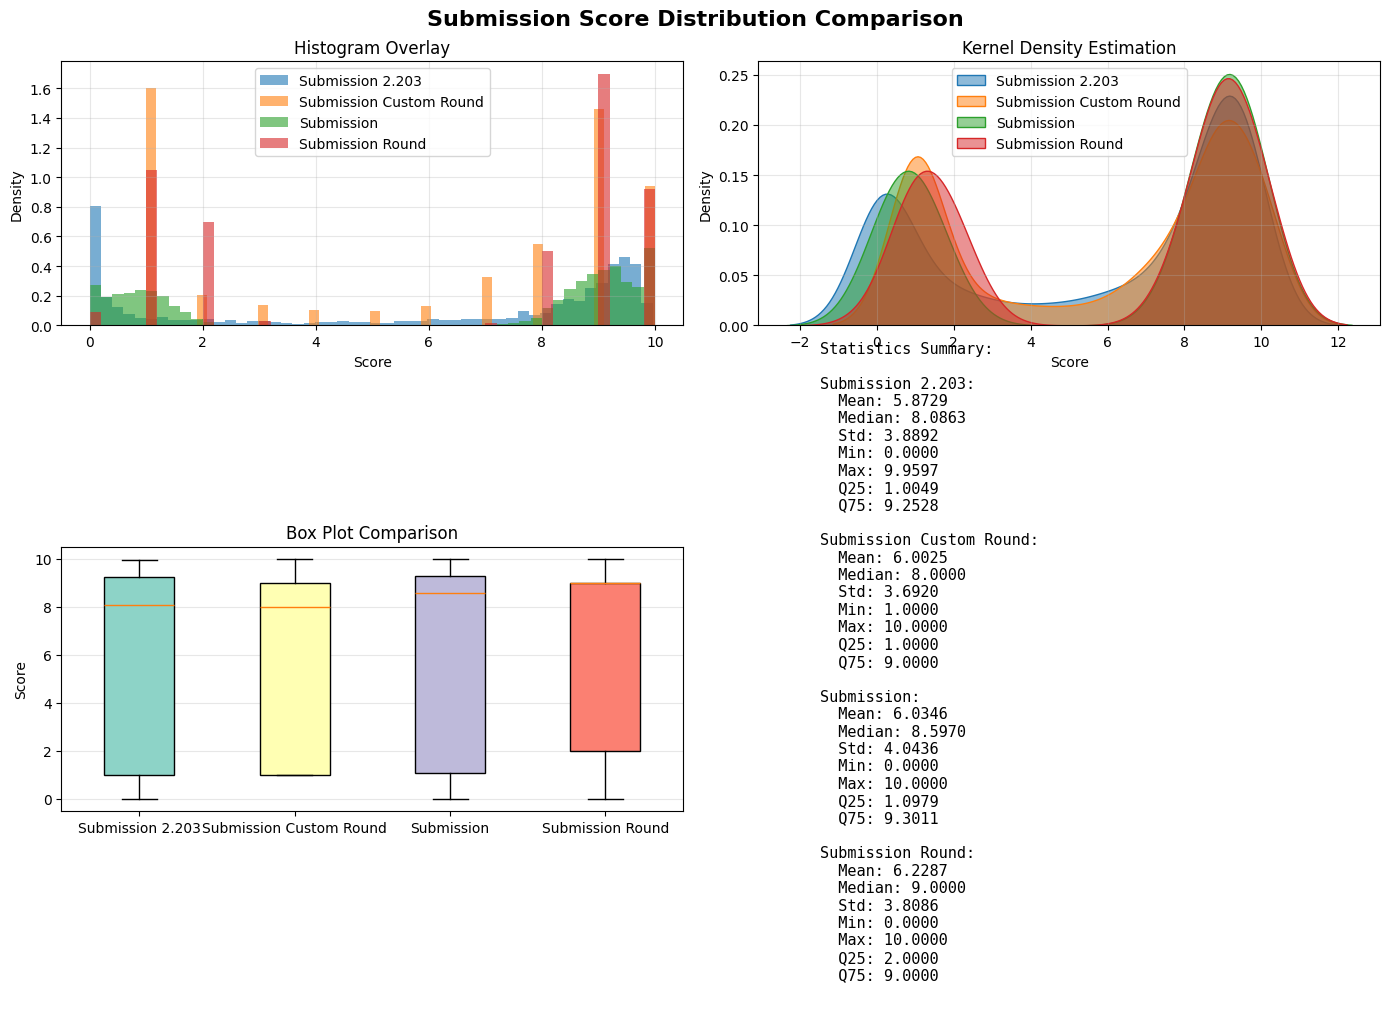

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
def plot_submission_distributions(file_paths, labels, title="Score Distribution Comparison"):
    """
    Plot distribution comparison of multiple submission files.
    
    Parameters:
    -----------
    file_paths : list of str
        Paths to submission CSV files
    labels : list of str
        Labels for each file (for legend)
    title : str
        Plot title
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # Load data
    data_dict = {}
    for file_path, label in zip(file_paths, labels):
        df = pd.read_csv(file_path)
        if 'score' in df.columns:
            data_dict[label] = df['score'].values
        else:
            print(f"Warning: 'score' column not found in {file_path}")
            continue
    
    # Plot 1: Histogram overlay
    ax1 = axes[0, 0]
    for label, scores in data_dict.items():
        ax1.hist(scores, bins=50, alpha=0.6, label=label, density=True)
    ax1.set_xlabel('Score')
    ax1.set_ylabel('Density')
    ax1.set_title('Histogram Overlay')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: KDE plot
    ax2 = axes[0, 1]
    for label, scores in data_dict.items():
        sns.kdeplot(scores, ax=ax2, label=label, fill=True, alpha=0.5)
    ax2.set_xlabel('Score')
    ax2.set_ylabel('Density')
    ax2.set_title('Kernel Density Estimation')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Box plot
    ax3 = axes[1, 0]
    plot_data = [scores for scores in data_dict.values()]
    bp = ax3.boxplot(plot_data, labels=list(data_dict.keys()), patch_artist=True)
    for patch, label in zip(bp['boxes'], data_dict.keys()):
        patch.set_facecolor(plt.cm.Set3(list(data_dict.keys()).index(label)))
    ax3.set_ylabel('Score')
    ax3.set_title('Box Plot Comparison')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Statistics summary
    ax4 = axes[1, 1]
    ax4.axis('off')
    stats_text = "Statistics Summary:\n\n"
    for label, scores in data_dict.items():
        stats_text += f"{label}:\n"
        stats_text += f"  Mean: {np.mean(scores):.4f}\n"
        stats_text += f"  Median: {np.median(scores):.4f}\n"
        stats_text += f"  Std: {np.std(scores):.4f}\n"
        stats_text += f"  Min: {np.min(scores):.4f}\n"
        stats_text += f"  Max: {np.max(scores):.4f}\n"
        stats_text += f"  Q25: {np.percentile(scores, 25):.4f}\n"
        stats_text += f"  Q75: {np.percentile(scores, 75):.4f}\n\n"
    ax4.text(0.1, 0.5, stats_text, fontsize=11, family='monospace', 
             verticalalignment='center', transform=ax4.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    return data_dict

# Plot distributions
file_paths = ["submission_2_203.csv", "submission_custom_round.csv","submission.csv", "submission_round.csv"]
labels = ["Submission 2.203", "Submission Custom Round","Submission", "Submission Round"]
data_dict = plot_submission_distributions(file_paths, labels, 
                                          title="Submission Score Distribution Comparison")
